# Naive Bayes 

Changelog

## What is it doing?

This model learns probability distribution for 3 types of labels according to the classification features i.e magnitude labels of celestial objects. 

Namely u, g, r, i, z magnitudes.


## Model Working

..


1. Importing libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv("sdss.csv")


In [3]:
features = ['u', 'g', 'r', 'i', 'z']
X = data[features]
y = data['class'] 

In [4]:
y = y.map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [7]:
y_pred = model.predict(X_test)

every row and column represents the five features like this:
    u x x x x x
    g x x x x x
    r x x x x x
    i x x x x x
    z u g r i z

- scatterplot shows relationship between those features at each intersection
- Diagonals have histograms (KDE plots) to show distribution of each feature for different class.

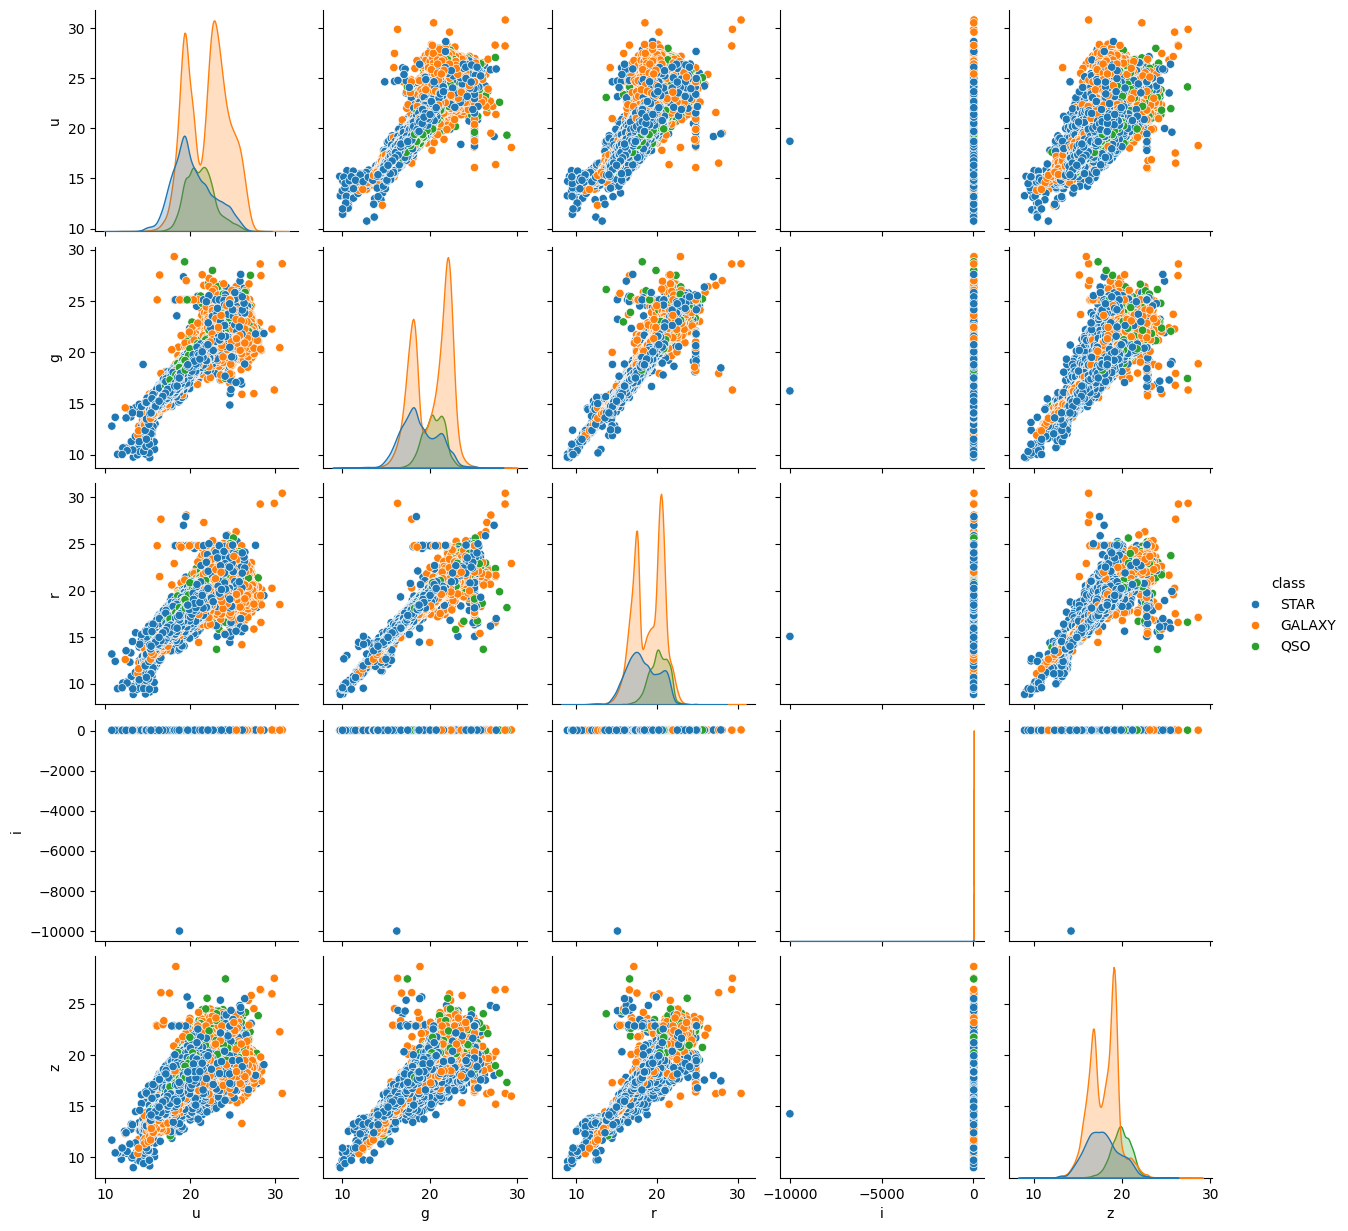

In [9]:
sns.pairplot(data, hue='class', vars=features)
plt.show()


u, g  and r  show distinct clusters especially with stars and galaxies. Which means model is performing very well

since i hs a lot of outliers, I will perform the classification again without i feature and see how it does

Accuracy report:

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.6167
              precision    recall  f1-score   support

           0       0.70      0.80      0.75     21574
           1       0.56      0.08      0.14      8537
           2       0.41      0.74      0.53      5310

    accuracy                           0.62     35421
   macro avg       0.56      0.54      0.47     35421
weighted avg       0.62      0.62      0.57     35421



Precision is highest with stars but that could be because there are more values in star feature. 

Confusion Matrix:

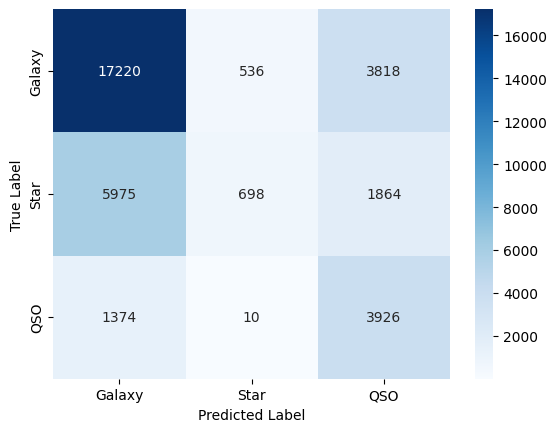

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


### Model misclassified 3818 galaxies as quasars and 5975 quasarsas galaxies.

wihtout i feature

In [15]:
features2 = ['u', 'g', 'r', 'z']
X2 = data[features2]
y = data['class'] 

In [16]:
y = y.map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size=0.3, random_state=42)

In [18]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [19]:
y_pred = model.predict(X_test)

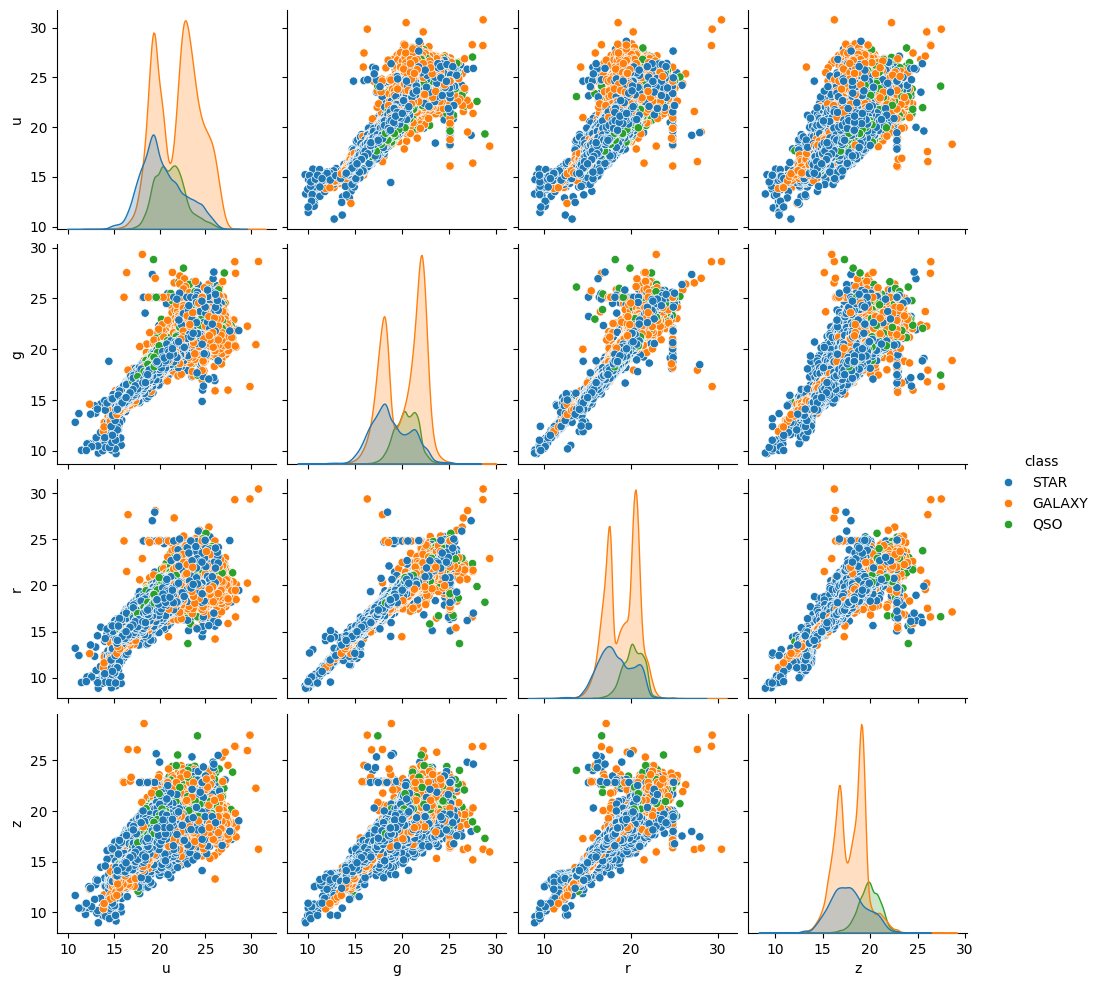

In [20]:
sns.pairplot(data, hue='class', vars=features2)
plt.show()


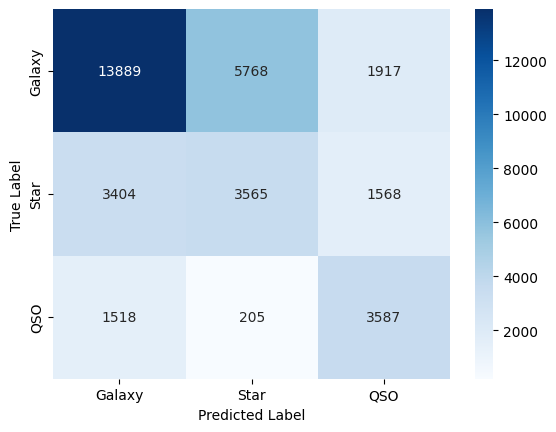

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
